- Cloth**Dataset** guarda la info d vertices x caracteristicas () al acceder a estos items con el **DataLoader** le añade la otra dimension d frames(batchsize) para crear el tensor3D
- Redondear valores para optimizar (ahorra memoria)

Otra idea sería:
> When to add a frame dimension (Sequence modeling): If your model needs temporal history—meaning it needs to look at, say, the last 5 frames to figure out what happens in the 6th frame. If you were using an LSTM, RNN, or a Spatiotemporal Transformer, your tensor would need to look like [Batch, Sequence_Length, Vertices, Features].
Por ahora no.

**Links Utilizados:**
- https://docs.pytorch.org/tutorials/beginner/data_loading_tutorial.html
- https://lixiaoguang.medium.com/build-cnn-from-scratch-5-convolutional-neural-network-86b4d0323fb0

In [17]:
from torch.utils.data import Dataset, DataLoader
import pandas as pd
import numpy as np
import io
import torch
import os, os.path

# WORKING WITH 
datasetPath = 'data/'

def loadAndMergeCSV(csvRoute):
    """
    Carga de los CSV y mergeo en un único CSV. Todos los CSV estarán en la ruta 'data/', y se excluirá el CSV
    'mergedCSV.csv', producto de los mergeos si se ejecutase antes
    """
    csvRoute= 'data/'
    finalData = pd.DataFrame()
    for csvfile in [f for f in os.listdir(csvRoute) if os.path.isfile(csvRoute + f)]:
        if (csvfile != 'mergedCSV.csv' and os.path.splitext(csvfile)[1] == '.csv'):
            data = pd.read_csv(csvRoute + csvfile)
            finalData = pd.concat([data, finalData], ignore_index=True)

    return finalData

cloth_info = loadAndMergeCSV(datasetPath)

print('cloth_info shape: {}'.format(cloth_info.shape))
print('cloth_info: \n{}'.format(cloth_info))

cloth_info shape: (468, 79)
cloth_info: 
     frame            x0        y0        z0        vx0       vy0       vz0  \
0        0 -4.216044e-08  1.499913  0.225583  -0.004361 -74.99863  0.000992   
1        1  1.820105e-02  1.500293  0.219883  -0.886701 -75.92898 -0.049198   
2        2 -1.066346e-01  1.511619  0.222103   5.462661 -70.14699  0.015023   
3        3 -1.996845e-01  1.541488  0.224504  12.126770 -67.12998 -0.001404   
4        4 -6.189827e-03  1.500170  0.222646   1.266535 -74.72750  0.020391   
..     ...           ...       ...       ...        ...       ...       ...   
463    463 -1.047743e-01  1.511029  0.223596   6.366400 -70.44193  0.041204   
464    464 -2.453499e-02  1.500698  0.224925   1.329836 -73.80412 -0.014795   
465    465 -7.667037e-02  1.505977  0.221374   3.542761 -71.37963  0.058286   
466    466 -2.373345e-01  1.559896  0.218972  14.427990 -65.90613 -0.060602   
467    467 -1.515977e-01  1.523507  0.225559   9.442355 -68.82992  0.005285   

         s

C:\Users\mikel\AppData\Local\Temp\ipykernel_29072\1152239316.py:26: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')


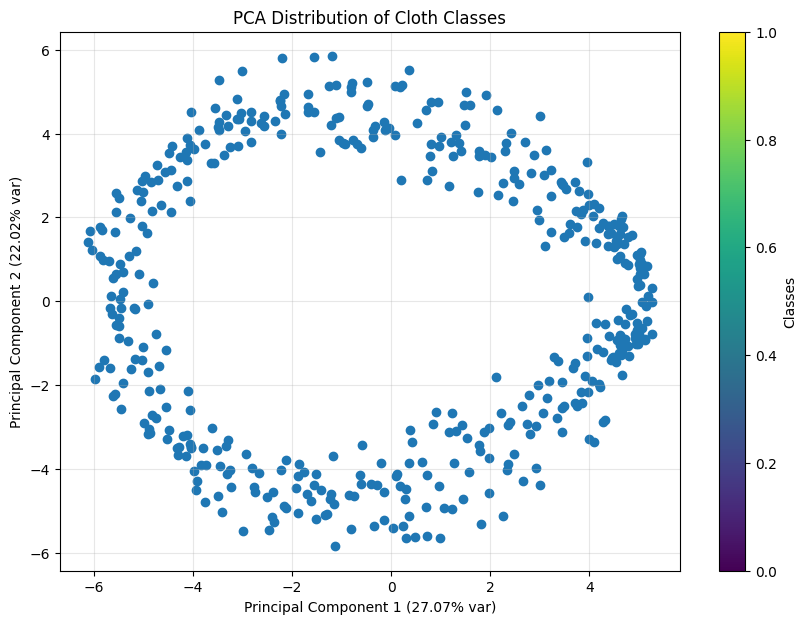

In [14]:
#Importación de funciones de los diferentes archivos
import pandas as pd
import numpy as np
import os
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import matplotlib.pyplot as plt

# Guardo todos los datos
df = pd.read_csv('data/clothDataset_20_.csv') 

# EJ2 - representar distribucion de clases con PCA

X = df

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 5. Apply PCA
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# 6. Visualizationplt.figure(figsize=(10, 7))
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], cmap='viridis')
plt.title('PCA Distribution of Cloth Classes')
plt.title('PCA Distribution of Cloth Classes')
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]:.2%} var)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]:.2%} var)')
plt.colorbar(scatter, label='Classes')
plt.grid(True, alpha=0.3)


plt.show()

In [18]:
class ClothDataset(Dataset):
    def __init__(self, csv_data, num_vertices=6):
        """
        Args:
            csv_data (str or filepath): Path to the CSV file or raw CSV string.
            num_vertices (int): Number of vertices per frame.
        """
        # Load the CSV data into a pandas DataFrame
        #if isinstance(csv_data, str) and "frame,x0" in csv_data:
            #self.data = pd.read_csv(io.StringIO(csv_data.strip()))
        #else:
            #self.data = pd.read_csv(csv_data)
        self.data = csv_data
            
        #quick fix para espacios en primera fila
        self.data.columns = self.data.columns.str.strip()
        
        self.num_vertices = num_vertices
        
        # Define the base feature names to extract per vertex
        self.feature_prefixes = ['x', 'y', 'z', 'vx', 'vy', 'vz', 'sdf', 'nx', 'ny', 'nz', 'md', 'u', 'v']

        self.position_prefixes = ['x', 'y', 'z']
        self.output_positions = self.data.filter(regex=r'^[xyz]\d+$')

        # Quitamos primera fila de outputs (no es el output de nada) y ultima fila de input (no tiene output)
        self.output_positions = self.output_positions.iloc[1:]
        self.data = self.data.iloc[:-1]
        

    def __len__(self):
        # The number of items is the number of frames (rows) in the dataset
        return len(self.data)
    
    def num_features(self):
        # Number of columns in a row (pos, vel, sdf, uv per vertex)
        return len(self.feature_prefixes)
    
    def num_vertex(self):
        return self.num_vertices
    
    def _get_frame_output_tensor(self, idx):
         row = self.output_positions.iloc[idx]
         frame_data = []
         for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.position_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

         tensor_data = torch.tensor(np.array(frame_data))

         return tensor_data
    
    def _get_frame_tensor(self, idx):
        row = self.data.iloc[idx]
        frame_data = []

        for i in range(self.num_vertices):
            vertex_cols = [f"{prefix}{i}" for prefix in self.feature_prefixes]
            vertex_features = row[vertex_cols].values.astype(np.float32)
            frame_data.append(vertex_features)

        tensor_data = torch.tensor(np.array(frame_data))

        return tensor_data
        
    def __getitem__(self, idx):
        frame_t = self._get_frame_tensor(idx)
        frame_t1 = self._get_frame_output_tensor(idx) # +1 ya no TODO: Pillar solo las columnas de pos

        return frame_t, frame_t1

# --- Example Usage ---

# (Assuming 'csv_string' is a variable holding your provided data block)
dataset = ClothDataset(cloth_info)
dataloader = DataLoader(dataset, batch_size=4, shuffle=True)

for batch_data, batch_frames in dataloader:
    print(f"Batch Shape: {batch_data.shape}")
    print(batch_data)
    print(batch_frames)
    break


mean = 0
std = 0
n_samples = 0

for batch_t, _ in dataloader:
    batch_t = batch_t.float()
    
    batch_samples = batch_t.size(0)
    batch_t = batch_t.view(-1, batch_t.size(-1))  

    mean += batch_t.mean(dim=0)
    std += batch_t.std(dim=0)
    n_samples += batch_t.size(0)

mean /= n_samples
std /= n_samples

# evitamos division por 0
std[std < 1e-8] = 1.0

print("MEAN:", mean)
print("STD:", std)


Batch Shape: torch.Size([4, 6, 13])
tensor([[[-1.8718e-01,  1.5363e+00,  2.2334e-01,  1.1163e+01, -6.7449e+01,
          -2.9051e-02,  4.9664e-01, -7.4934e-01,  5.0799e-01,  4.2477e-01,
           1.0000e+00,  5.0000e-01,  0.0000e+00],
         [-2.8318e-01,  1.0404e+00, -2.2214e-01, -9.3223e+00, -3.7703e+01,
          -9.2531e-02,  3.4317e-01, -9.9958e-01,  1.2364e-02, -2.6253e-02,
           1.0000e+00,  1.0000e+00,  1.0000e+00],
         [-3.6577e-01,  1.0688e+00,  2.2024e-01, -4.4514e+00, -3.4733e+01,
          -2.2373e-01,  5.1710e-01, -9.0985e-01,  3.8149e-02,  4.1317e-01,
           1.0000e+00,  1.0000e+00,  0.0000e+00],
         [-1.2522e-01,  1.5160e+00, -2.2288e-01,  7.3292e+00, -6.9612e+01,
           1.4287e-02,  3.4010e-01, -8.1521e-01,  5.7852e-01, -2.7234e-02,
           1.0000e+00,  5.0000e-01,  1.0000e+00],
         [-5.9605e-08,  2.0000e+00,  2.2550e-01,  2.5000e+01, -1.0000e+02,
           0.0000e+00,  6.9798e-01, -4.6716e-01,  8.0970e-01,  3.5518e-01,
           0.0

In [32]:
import json
# Intento de normalización uep

# Convertir tensores a listas
norm_data = {
    "mean": mean.tolist(),
    "std": std.tolist(),
    "feature_prefixes": ['x', 'y', 'z', 'vx', 'vy', 'vz', 'sdf', 'nx', 'ny', 'nz', 'md', 'u', 'v']
}

with open("cloth_norm_params.json", "w") as f:
    json.dump(norm_data, f)

In [19]:
# TODO
# una recurrente sencilla (la salida se vuelve entrada en el siguiente ejemplo)
# Antes de meternos en CNN y LSTM
# AÑADIMOS VALORES U V PARA CADA VERTICE ( no queremos perder la noción espacial )

import torch.nn as nn
import torch.nn.functional as F #acceso rapido a funciones
import torch.utils.data as data #cargar y manejar el training data

class MyModule(nn.Module):

    def __init__(self, num_inputs, num_hidden, num_outputs):
        super().__init__()
        # Some init for my module
        self.linear1 = nn.Linear(num_inputs, num_hidden)
        self.relu = nn.ReLU()
        self.linear2 = nn.Linear(num_hidden, num_outputs)

    def forward(self, x):
        # Function for performing the calculation of the module.
        
        x = self.linear1(x)
        x = self.relu(x)
        x = self.linear2(x)
        #print(x)
        return x

    #backward se hace automaticamente, podriamos definirla tmbn 

#tmbn clases DataSet y DataLoader

# definir modelo, loss function y optimizer
#TODO: buscar dimensiones reales de las neuronas

# nn.Linear in PyTorch is designed to handle 3D tensors seamlessly.  
# When a 3D input tensor (e.g., batch_size, sequence_length, features) is provided,
#  the layer applies the linear transformation only to the last dimension (the features dimension),
#  preserving all other dimensions.

model = MyModule(num_inputs=13, num_hidden= 64, num_outputs=3)
# print, save, lo que sea
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

start training
Train Epoch 001
Epoch 001 | Test Loss: 0.054549 | Vertex Error: 8.301332 units
Epoch 001 | Test Loss: 0.089023 | Vertex Error: 15.065392 units
Epoch 001 | Test Loss: 0.155464 | Vertex Error: 24.053325 units
Epoch 001 | Test Loss: 0.217973 | Vertex Error: 33.088803 units
Epoch 001 | Test Loss: 0.297193 | Vertex Error: 42.950764 units
Epoch 001 | Test Loss: 0.369527 | Vertex Error: 52.320225 units
Epoch 001 | Test Loss: 0.419916 | Vertex Error: 60.271112 units
Epoch 001 | Test Loss: 0.478274 | Vertex Error: 68.786016 units
Epoch 001 | Test Loss: 0.532393 | Vertex Error: 76.712941 units
Epoch 001 | Test Loss: 0.596479 | Vertex Error: 85.538277 units
Epoch 001 | Test Loss: 0.644742 | Vertex Error: 93.538785 units
Epoch 001 | Test Loss: 0.708881 | Vertex Error: 102.426806 units
Epoch 001 | Test Loss: 0.730995 | Vertex Error: 108.035458 units
Epoch 001 | Test Loss: 0.796312 | Vertex Error: 117.530839 units
Epoch 001 | Test Loss: 0.843930 | Vertex Error: 125.455826 units
Epoch 

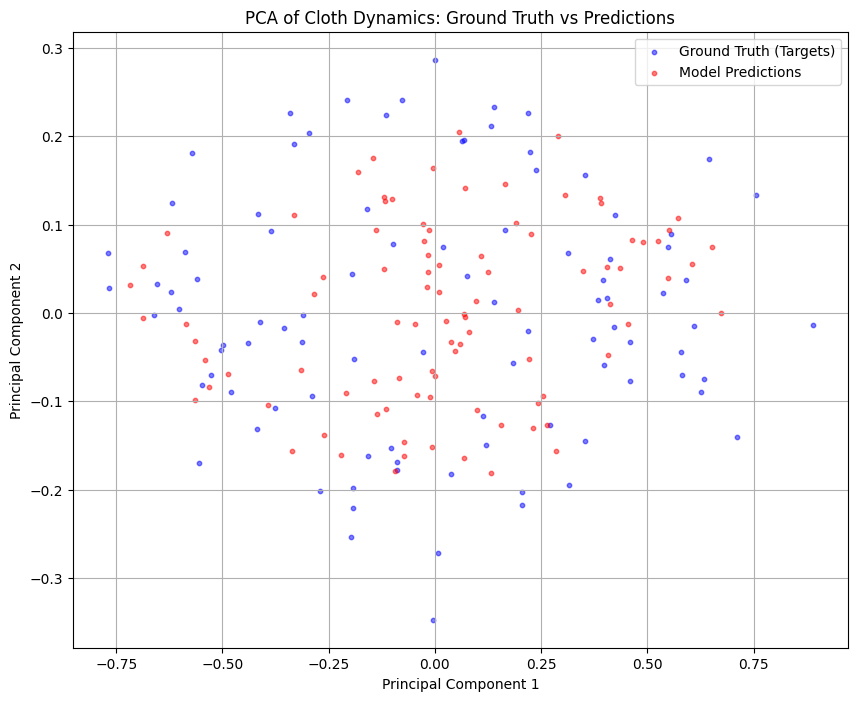

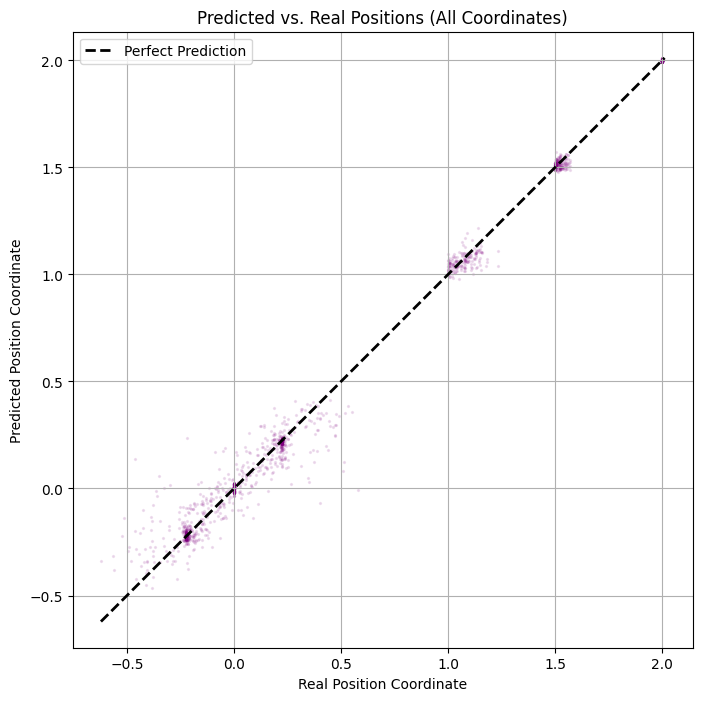

IndexError: index 150 is out of bounds for axis 0 with size 94

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import numpy as np

# ... [Keep your ClothDataset and MyModule classes exactly as they are] ...

dataset = ClothDataset(cloth_info)

# 1. SPLIT THE DATA (80% Training, 20% Testing)
train_size = int(0.8 * len(dataset))
test_size = len(dataset) - train_size
train_dataset, test_dataset = random_split(dataset, [train_size, test_size])

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False) # No need to shuffle test data

# 2. COMPUTE GLOBAL STATS (Only on training data to prevent data leakage)
mean_in = 0
std_in = 0
n_samples = 0

for batch_t, _ in train_loader:
    batch_t = batch_t.float()
    batch_t_flat = batch_t.view(-1, batch_t.size(-1))  
    mean_in += batch_t_flat.mean(dim=0)
    std_in += batch_t_flat.std(dim=0)
    n_samples += 1

global_in_mean = mean_in / n_samples
global_in_std = std_in / n_samples
global_in_std[global_in_std < 1e-8] = 1.0

# 3. SETUP MODEL
model = MyModule(num_inputs=13, num_hidden=64, num_outputs=3)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

print("start training")

# 4. TRAINING & TESTING LOOP
epochs = 50
for epoch in range(epochs):
    
    # --- TRAINING PHASE ---
    model.train() # Set model to training mode
    train_loss = 0.0
    
    for batch_t, batch_t1 in train_loader:
        batch_t = batch_t.float()
        batch_t1 = batch_t1.float()

        # Normalize Input globally
        batch_t_norm = (batch_t - global_in_mean) / global_in_std

        # Target is the DISPLACEMENT (Delta), not the absolute position
        positions_t = batch_t[..., 0:3] 
        target_delta = batch_t1 - positions_t
        
        # Note: For best results, target_delta should also be globally normalized, 
        # but we will keep it raw here for easier "Distance Error" calculation later.

        pred_delta = model(batch_t_norm)
        loss = criterion(pred_delta, target_delta)

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        
        train_loss += loss.item()
        
    print(f'Train Epoch {epoch+1:03d}')
        
    avg_train_loss = train_loss / len(train_loader)

    # --- TESTING/VALIDATION PHASE ---
    model.eval() # Set model to evaluation mode
    test_loss = 0.0
    total_distance_error = 0.0
    total_vertices = 0

    all_pred_deltas = []
    all_target_deltas = []

    all_pred_pos = []
    all_target_pos = []
    
    with torch.no_grad(): # Disable gradient calculation for testing (saves memory & speeds up)
        for batch_t, batch_t1 in test_loader:
            batch_t = batch_t.float()
            batch_t1 = batch_t1.float()

            batch_t_norm = (batch_t - global_in_mean) / global_in_std
            
            positions_t = batch_t[..., 0:3] 
            target_delta = batch_t1 - positions_t

            pred_delta = model(batch_t_norm)
            loss = criterion(pred_delta, target_delta)
            test_loss += loss.item()

            # --- NEW: Reconstruct the absolute positions ---
            pred_pos = positions_t + pred_delta
            target_pos = batch_t1[..., 0:3] # The true final position

            # Store them
            all_pred_pos.append(pred_pos.cpu().numpy())
            all_target_pos.append(target_pos.cpu().numpy())
            
            # Calculate our "Accuracy" (Mean Distance Error per vertex)
            # Distance = sqrt((dx_pred - dx_true)^2 + (dy_pred - dy_true)^2 + (dz_pred - dz_true)^2)
            distances = torch.norm(pred_delta - target_delta, dim=-1) # Calculates Euclidean distance
            total_distance_error += distances.sum().item()
            total_vertices += distances.numel()

            # --- NEW: Store the data for PCA ---
            # Move tensors to the CPU and convert to NumPy arrays immediately
            all_pred_deltas.append(pred_delta.cpu().numpy())
            all_target_deltas.append(target_delta.cpu().numpy())

            print(f'Epoch {epoch+1:03d} | Test Loss: {test_loss:.6f} | Vertex Error: {total_distance_error:.6f} units')

    avg_test_loss = test_loss / len(test_loader)
    avg_distance_error = total_distance_error / total_vertices

    # Combine into large arrays
    # Shapes will be: (Total_Frames, Vertices, 3)
    preds_pos_np = np.concatenate(all_pred_pos, axis=0)
    targets_pos_np = np.concatenate(all_target_pos, axis=0)

    print(f'Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.6f} | Test Loss: {avg_test_loss:.6f} | Avg Vertex Error: {avg_distance_error:.6f} units')

    from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. Combine the collected batches into single large arrays
preds_np = np.concatenate(all_pred_deltas, axis=0)     # Shape: (Total_Frames, Vertices, 3)
targets_np = np.concatenate(all_target_deltas, axis=0) # Shape: (Total_Frames, Vertices, 3)

# 2. Reshape to 2D: (Total_Frames, Vertices * 3)
preds_2d = preds_np.reshape(preds_np.shape[0], -1)
targets_2d = targets_np.reshape(targets_np.shape[0], -1)

# 3. Initialize PCA
pca = PCA(n_components=2) # 2 components for a 2D scatter plot

# CRITICAL: Fit the PCA on the TARGETS (Ground Truth) to define the coordinate space.
# If you fit two separate PCAs, the axes will mean different things and you cannot compare them!
pca.fit(targets_2d)

# Transform both datasets into this shared PCA space
pca_targets = pca.transform(targets_2d)
pca_preds = pca.transform(preds_2d)

# 4. Plot the comparison
plt.figure(figsize=(10, 8))

# Plot ground truth in blue
plt.scatter(pca_targets[:, 0], pca_targets[:, 1], alpha=0.5, label='Ground Truth (Targets)', color='blue', s=10)

# Plot predictions in red
plt.scatter(pca_preds[:, 0], pca_preds[:, 1], alpha=0.5, label='Model Predictions', color='red', s=10)

plt.title('PCA of Cloth Dynamics: Ground Truth vs Predictions')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.grid(True)
plt.show()

import matplotlib.pyplot as plt

# Flatten the arrays so we just have a massive list of X, Y, and Z coordinates
true_flat = targets_pos_np.reshape(-1)
pred_flat = preds_pos_np.reshape(-1)

plt.figure(figsize=(8, 8))
plt.scatter(true_flat, pred_flat, alpha=0.1, color='purple', s=2)

# Draw the perfect prediction line (y = x)
min_val = min(true_flat.min(), pred_flat.min())
max_val = max(true_flat.max(), pred_flat.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Prediction')

plt.title('Predicted vs. Real Positions (All Coordinates)')
plt.xlabel('Real Position Coordinate')
plt.ylabel('Predicted Position Coordinate')
plt.legend()
plt.grid(True)
plt.axis('equal') # Keeps the aspect ratio square
plt.show()

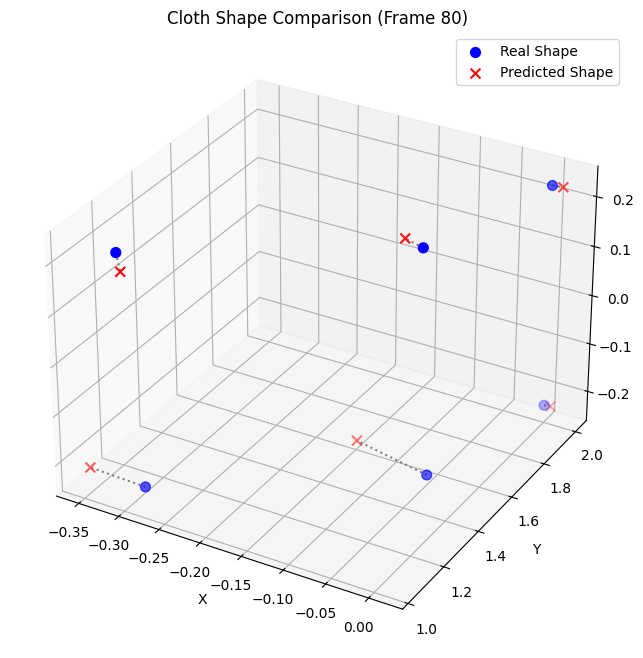

In [30]:
# Choose a random frame from your test set to visualize
frame_idx = 80 # Change this to look at different moments
num_vertices = targets_pos_np.shape[1]

real_frame = targets_pos_np[frame_idx] # Shape: (Vertices, 3)
pred_frame = preds_pos_np[frame_idx]   # Shape: (Vertices, 3)

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# Extract X, Y, Z for Real positions
rx, ry, rz = real_frame[:, 0], real_frame[:, 1], real_frame[:, 2]
# Extract X, Y, Z for Predicted positions
px, py, pz = pred_frame[:, 0], pred_frame[:, 1], pred_frame[:, 2]

# Plot the real cloth vertices in Blue
ax.scatter(rx, ry, rz, c='blue', label='Real Shape', s=50, marker='o')

# Plot the predicted cloth vertices in Red
ax.scatter(px, py, pz, c='red', label='Predicted Shape', s=50, marker='x')

# Draw lines connecting the predicted vertex to the real vertex to show the error
for i in range(num_vertices):
    ax.plot([rx[i], px[i]], [ry[i], py[i]], [rz[i], pz[i]], color='gray', linestyle='dotted')

ax.set_title(f'Cloth Shape Comparison (Frame {frame_idx})')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')
ax.legend()
plt.show()

In [31]:
import torch
import sys
import onnx
import onnxruntime

# 1. Load your trained model (make sure it's in eval mode)
model.eval()

# 2. Create a dummy input strictly enforcing the 3D shape: (Batch=3, Vertices=6, Features=13)
# It doesn't matter what the numbers are, ONNX just needs the shape.
dummy_input = torch.randn(1, 6, 13)

# 3. Export to ONNX
onnx_program = torch.onnx.export(
    model,                      # Your trained PyTorch model
    dummy_input,                # The strictly 3D input tensor
    "cloth_graphed.onnx",         # Output file name
    export_params=True,         # Store the trained weights
    opset_version=9,            # Sentis handles opset 9-15 well
    input_names=['input'],      # Name the input for Unity
    output_names=['output'],    # Name the output for Unity
)

print("Exported to ONNX with strict 3D shapes!")

Exported to ONNX with strict 3D shapes!


In [20]:
#INTENTO DE EXPORTAR A ONNX
import sys
print(sys.executable)

import onnx
import onnxruntime

print("ONNX version:", onnx.__version__)
print("ONNX Runtime version:", onnxruntime.__version__)

# Create example inputs for exporting the model. The inputs should be a tuple of tensors.
example_inputs = (batch_t)
onnx_program = torch.onnx.export(model, example_inputs, dynamo=True)

onnx_program.save("onnxModels/trainedLinear6Model.onnx")

c:\Users\mikel\miniconda3\envs\dl2024\python.exe
ONNX version: 1.21.0
ONNX Runtime version: 1.24.4
[torch.onnx] Obtain model graph for `MyModule([...]` with `torch.export.export`...
[torch.onnx] Obtain model graph for `MyModule([...]` with `torch.export.export`... ✅
[torch.onnx] Translate the graph into ONNX...


W0420 12:41:02.641000 27016 site-packages\torch\onnx\_internal\exporter\_schemas.py:446] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 12:41:02.643000 27016 site-packages\torch\onnx\_internal\exporter\_schemas.py:446] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0, sampling_ratio: 'int' = -1, aligned: 'bool' = False). Treating as an Input.
W0420 12:41:02.646000 27016 site-packages\torch\onnx\_internal\exporter\_schemas.py:446] Missing annotation for parameter 'input' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 'float' = 1.0). Treating as an Input.
W0420 12:41:02.648000 27016 site-packages\torch\onnx\_internal\exporter\_schemas.py:446] Missing annotation for parameter 'boxes' from (input, boxes, output_size: 'Sequence[int]', spatial_scale: 

[torch.onnx] Translate the graph into ONNX... ✅
